In [1]:
using Revise
includet("../../scripts/single_influx.jl")
import SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.MinimalModelV3

In [2]:
using ProgressMeter
using ColorSchemes
using UnPack

In [3]:
includet("../../scripts/ternary_colormap.jl")
using .TernaryColormaps

In [4]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Load data (~20s, once "Process data" cache exists)

In [194]:
# The main dataset for the phase diagram in fig. 2, K and li sampled at decent density
includet("../../cluster_env/runs/single_influx3/base.jl")
f1 = jldopen("../../cluster_env/runs/single_influx3/main1.jld2")
f1df = f1["df"]
f1cmats = make_count_matrices(f1df);

f1md = f1["metadata"]
f1Ks = f1md.Ks
f1lis = f1md.lis
f1leakxs = LeakageScale.ltox.(f1md.lis);

In [195]:
# A smaller run for the proportions plot in fig. 1 at li precisely 0.999, 0.99, 0.9 and 0.75
f3 = jldopen("../../cluster_env/runs/single_influx2/gd1_260731_115325.jld2")
@time small_Ks, small_lis, small_rslts = make_Kli_matrix(f3);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00

  9.526555 seconds (9.85 M allocations: 2.139 GiB, 22.56% gc time, 25.89% compilation time: 7% of which was recompilation)

# Dominant outcomes PD V2 with inset

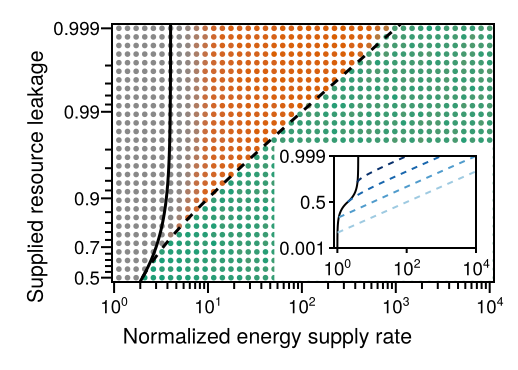

In [207]:
plotline_gpcols = [
    (1., 1., :black),
    # (0.32, 1., (:purple, 0.6)),
]

fig = Figure(;
    size=(double_col_width * 0.38, (double_col_width / golden_ratio) * 0.44),
    figure_padding=(12., 12., 12., 12.),
)
ax = Axis(fig[1,1];
    # aspect=AxisAspect(1.2),
    xscale=log10,
    xlabelsize=8fontsize_pt,
    ylabelsize=8fontsize_pt,
    xlabelpadding=3.,
    ylabelpadding=3.,
    xlabel="Normalized energy supply rate            ",
    ylabel="Supplied resource leakage        ",
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    xticks=log10ticks(-1:4),
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(10),
    yminorticksvisible=true,
    xgridvisible=false,
    ygridvisible=false,
)
eps_ticks = [0.5, 0.3, 0.1, 0.01, 0.001]
ax.yticks = (LeakageScale.etox.(eps_ticks), [(@sprintf "%.3g" (1-e)) for e in eps_ticks])
ax.yminorticks = LeakageScale.exminorticks(eps_ticks, 4)
# ax.ylabel = L"l,\enspace\text{Supplied resource leakage}"
# ax.ylabel = L"l,\enspace\text{Supplied resource byproduct ratio}"
# ax.xlabel = L"K,\enspace\text{Amount of energy being supplied}"
# ax.xlabel = L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}"

cm = TernaryColormap(PaperColors.extinct(), PaperColors.stable(), PaperColors.unstable())
xx = collect(zip(f1cmats[1], f1cmats[2], f1cmats[3]));
yy = map(xx) do t t ./ sum(t) end;
pd_colors = cm.(yy)'[:]

scatter!(ax, [(x, y) for x in f1Ks for y in f1leakxs];
    # marker='.',
    markersize=4,
    color=pd_colors,
)

# pad the limits by half a grid step so the edge markers aren't cut in half
lKs = log10.(f1Ks)
xlim_lo = 10 ^ (lKs[1] - (lKs[2] - lKs[1]) / 2)
xlim_hi = 10 ^ (lKs[end] + (lKs[end] - lKs[end-1]) / 2)
ylim_lo = f1leakxs[1] - (f1leakxs[2] - f1leakxs[1]) / 2
ylim_hi = f1leakxs[end] + (f1leakxs[end] - f1leakxs[end-1]) / 2

for (gamma, p, color) in plotline_gpcols
    thr_leakxs = range(ylim_lo, ylim_hi, 1000)
    thr_ls = LeakageScale.l.(thr_leakxs)

    extline_Ks = MinimalModelV3.fr3_beta_viable.(thr_ls, gamma)
    instabline_Ks = MinimalModelV3.fr3_beta_s_qualified.(thr_ls, gamma, p)

    lines!(ax, extline_Ks, thr_leakxs;
        color,
    )
    lines!(ax, instabline_Ks, thr_leakxs;
        color,
        linestyle=:dash,
    )

    # xlims!(ax, xlim_lo, xlim_hi)
    xlims!(ax, 0.95, xlim_hi)
    ylims!(ax, ylim_lo, ylim_hi)
end

# ----- inset: instability region changing with p (bottom right) -----
# ins_lticks = [0.001, 0.05, 0.5, 0.95, 0.999]
ins_lticks = [0.001, 0.5, 0.999]
ins_logps = range(1., -2, 4)
ins_cmap = cgrad(ColorSchemes.Blues[4:end])

# opaque backdrop so the inset (and its tick labels) sit clear of the scatter
ins_bg = Box(fig[1,1];
    width=Relative(0.57),
    height=Relative(0.53),
    halign=1. - 1e-2,
    valign=0.0 + 1e-2,
    color=:white,
    strokevisible=false,
)

iax = Axis(fig[1,1];
    width=Relative(0.37),
    height=Relative(0.36),
    halign=0.924,
    valign=0.20,
    xscale=log10,
    xticks=log10ticks(0:2:4),
    yticks=(LeakageScale.ltox.(ins_lticks), string.(ins_lticks)),
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=1.,
    yticklabelpad=1.,
    xticksize=2.,
    yticksize=2.,
    xgridvisible=false,
    ygridvisible=false,
)

translate!(ins_bg.blockscene, 0, 0, 100)
translate!(iax.blockscene, 0, 0, 150)

ins_leakxs = range(LeakageScale.ltox(0.001), LeakageScale.ltox(0.999), 1000)
ins_ls = LeakageScale.l.(ins_leakxs)

lines!(iax, MinimalModelV2.fr_ext_line_K.(ins_ls, 1., 1.), ins_leakxs;
    color=:black,
    linewidth=1.,
)

for logp in ins_logps
    ins_p = 10 ^ logp
    lines!(iax, MinimalModelV2.fr_cor1_instab_line_K.(ins_ls, 1., 1., ins_p), ins_leakxs;
        color=get(ins_cmap, (logp - minimum(ins_logps)) / (maximum(ins_logps) - minimum(ins_logps))),
        linestyle=:dash,
        linewidth=1.,
        # label=rich("p=10", superscript(@sprintf "%.3g" logp)),
        label=latexstring("p=10^{" * (@sprintf "%d" logp) * "}"),
    )
end

# xlims!(iax, extrema(Ks))
xlims!(iax, 0.8, 1e4)
ylims!(iax, extrema(ins_leakxs))

# ax.ylabelpadding = -3.

Makie.save("../../figures2/fig2/outcomes_pd_v2.pdf", fig)

fig

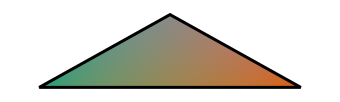

In [293]:
fig = Figure(;
    size=(double_col_width * 0.25, (double_col_width / golden_ratio) * 0.12),
    figure_padding=(0., 0., 0., 0.),
)
ternary_legend!(fig, cm;
    labels=("", "", ""),
    ticks=[],
    axiskwargs=(; aspect=AxisAspect(3.5)),
    resolution=16,
)

Makie.save("../../figures2/fig2/outcomes_colormap.pdf", fig)

fig

# lstar wrt p

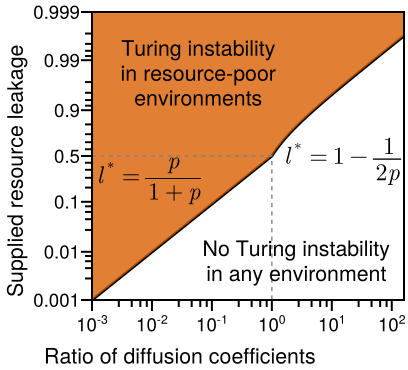

In [10]:
lticks = [0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999]

fig = Figure(;
    size=(double_col_width * 0.30, 0.44 * double_col_width / golden_ratio),
    figure_padding=(2., 2., 2., 6.),
)

ax = Axis(fig[1, 1];
    # labels
    xscale=log10,
    xlabel="Ratio of diffusion coefficients                       ",
    ylabel="Supplied resource leakage     ",
    xlabelsize=8fontsize_pt,
    ylabelsize=8fontsize_pt,
    xlabelpadding=4.,
    ylabelpadding=3.,
    # ticks style
    yticks=(LeakageScale.ltox.(lticks), string.(lticks)),
    yminorticksvisible=true,
    yminorticks=LeakageScale.lxminorticks(lticks, 4),
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(5),
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    xgridvisible=false,
    ygridvisible=false,
)

ps = 10 .^ range(-3, 3, 1000)
lstars = MinimalModelV3.fr3_lstar.(ps, 1.)
lines!(ax, ps, LeakageScale.ltox.(lstars);
    color=:black,
    label="Minimal leakage    ",
)
band!(ax, ps, LeakageScale.ltox.(lstars), fill(LeakageScale.ltox(0.999), length(ps));
    color=(PaperColors.unstable(), 0.8),
)
lines!(ax, [0.0001, 1., 1.], LeakageScale.ltox.([0.5, 0.5, 0.00001]);
    color=:gray,
    linestyle=:dash,
    linewidth=0.7,
)

# for g in [100, 10, 0.1, 0.01]
#     lstars2 = MinimalModelV3.fr3_lstar.(ps, g)
#     lines!(ax, ps, LeakageScale.ltox.(lstars2);
#         color=:gray,
#         linestyle=:dash,
#     )
# end

text!(ax, [(1.6, LeakageScale.ltox(0.2)), (0.0012, LeakageScale.ltox(0.09))];
    text=[
        L"l^*=1-\frac{1}{2p}",
        L"l^*=\frac{p}{1+p}",
    ],
    fontsize=8fontsize_ltex_pt,
    justification=:center,
)

text!(ax, [(0.003, LeakageScale.ltox(0.9)), (0.07, LeakageScale.ltox(0.002))];
    text=[
        "Turing instability\nin resource-poor\nenvironments",
        "No Turing instability\nin any environment"
    ],
    fontsize=8fontsize_pt,
    justification=:center,
)
# axislegend(ax;
#     position=:rb,
#     labelsize=8fontsize_pt,
#     patchsize=(10., 6.),
#     patchlabelgap=4.,
#     # colgap=6.,
#     # rowgap=2.,
#     framevisible=false,
#     padding=(0., 0., 0., 0.),
# )

ylims!(ax, LeakageScale.ltox(0.001), LeakageScale.ltox(0.999))
xlims!(ax, 0.001, 160.)

ax.xticks = log10ticks(-3:2)

Makie.save("../../figures2/fig2/lstar_vs_p.pdf", fig)

# display(GLMakie.Screen(), fig)

fig


# Proportions plot

faflis = Any[0.999, 0.99, 0.9, 0.75]
size(fig.layout) = (5, 3)

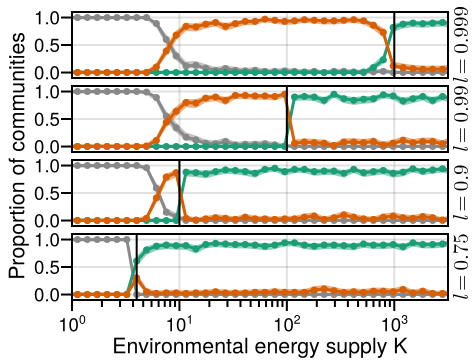

In [9]:
faflis = []
fafcounts = Any[]

for i in 2:5
    push!(faflis, small_lis[i])
    push!(fafcounts, small_rslts[:,i])
end
@show faflis
faflabels = [
    L"l=0.999",
    L"l=0.99",
    L"l=0.9",
    L"l=0.75",
]

fig = Figure(;
    size=(double_col_width * 0.35, 0.43 * double_col_width / golden_ratio),
    figure_padding=(2., 2., 2., 6.),
)

axs = []
for i in 1:length(faflis)
    li = faflis[i]
    cs = fafcounts[i]

    ax = Axis(fig[i,1];
        xscale=log10,
        xticklabelsize=7fontsize_pt,
        yticklabelsize=7fontsize_pt,
        xticklabelpad=0.,
        yticklabelpad=0.,
        xticks=log10ticks(0:5),
        xminorticksvisible=true,
        xminorticks=IntervalsBetween(10),
    )
    push!(axs, ax)
    Label(fig[i,2], faflabels[i];
        rotation=pi/2,
        tellheight=false,
        fontsize=7fontsize_ltex_pt,
    )
    
    num_runs = [x.num_runs for x in cs]
    plot_binom_sample!(ax, small_Ks, [x.extinct for x in cs], num_runs;
        color=PaperColors.extinct(),
        sl_kwargs=(; markersize=5.),
        proportions=true,
    )
    plot_binom_sample!(ax, small_Ks, [x.nonext_stable for x in cs], num_runs;
        color=PaperColors.stable(),
        sl_kwargs=(; markersize=5.),
        proportions=true,
    )
    plot_binom_sample!(ax, small_Ks, [x.nonext_unstable for x in cs], num_runs;
        color=PaperColors.unstable(),
        sl_kwargs=(; markersize=5.),
        proportions=true,
    )
        
    thrbdr = 1 / (1 - li)
    if isfinite(thrbdr)
        vlines!(ax, thrbdr;
            color=:black,
            linewidth=1.,
        )
    end

    xlims!(ax, 1, 10 ^ 3.5)
    ylims!(ax, -0.1, 1.1)
end

for i in 1:(length(axs)-1)
    linkxaxes!(axs[end], axs[i])
    hidexdecorations!(axs[i]; grid=false)
end

Label(fig[1:4,0], "Proportion of communities";
    rotation=pi/2,
    tellheight=false,
    fontsize=8fontsize_pt,
)
Label(fig[5,1], "Environmental energy supply K";
    tellwidth=false,
    fontsize=8fontsize_pt,
)
@show size(fig.layout)

rowgap!(fig.layout, 4.)
rowgap!(fig.layout, 4, 0.)
colgap!(fig.layout, 1, 4.)
colgap!(fig.layout, 2, 2.)

Makie.save("../../figures2/fig1/outcomes.pdf", fig)

fig

# Well-mixed total biomass vs K plot

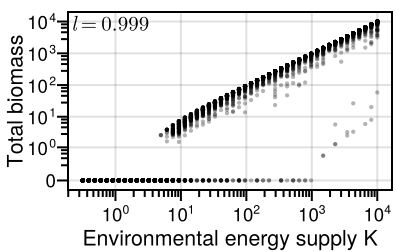

In [8]:
tbli = f1md.lis[end]
tbdf = @subset(f1df, :liis .== maximum(f1df.liis), :codes .> 0);
tbdf.K = f1md.Ks[tbdf.Kis]
tbdf.hss_biomass = map(tbdf.final_states) do fs sum(fs[1:f1md.N]) end;
tbdf.hss_biomass_clamped = clamp.(tbdf.hss_biomass, 0., Inf);

# smallest nonzero biomass is ~0.21, so the linear core sits just below the data and
# the extinct points at 0 stay ~0.5 decades clear of the smallest surviving ones
linthresh = 0.1

fig = Figure(;
    size=(double_col_width * 0.29, 0.3 * double_col_width / golden_ratio),
    figure_padding=(2., 2., 2., 6.),
)

ax = Axis(fig[1,1];
    xlabel="Environmental energy supply K",
    ylabel="Total biomass",
    xlabelsize=8fontsize_pt,
    ylabelsize=8fontsize_pt,
    ylabelpadding=0.,
    xlabelpadding=0.,
    xscale=log10,
    # symlog so the exactly-zero (extinct) biomasses are on the axis
    CustomSymlogScale.kwargs(linthresh; nminor=4)...,
    yticks=CustomSymlogScale.ticks([0.; 10.0 .^ (0:4)]),
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    xticks=log10ticks(0:4),
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(10),
)

scatter!(ax, tbdf.K, tbdf.hss_biomass_clamped;
    # color=(color, 0.3),
    color=(:black, 0.3),
    markersize=3.,
    strokewidth=0.,
)

# xlims!(ax, 10^-0.6, 10^4.2)
ylims!(ax, -linthresh, 2e4)

text!(ax, 0.01, 0.99;
    text=latexstring(@sprintf "l=%.3f" tbli),
    space=:relative,
    align=(:left, :top),
    fontsize=7fontsize_ltex_pt,
)

Makie.save("../../figures2/fig1/hss_biomass.pdf", fig)

fig

# lstar wrt p alternate

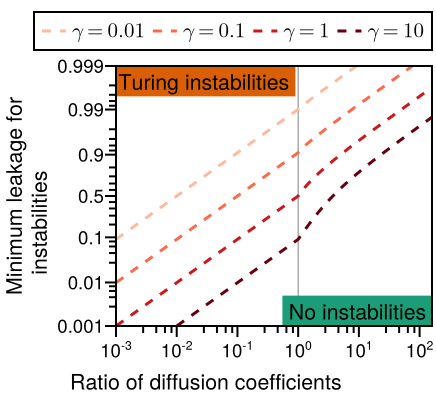

In [274]:
lticks = [0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999]

fig = Figure(;
    size=(double_col_width * 0.32, 0.47 * double_col_width / golden_ratio),
    figure_padding=(2., 2., 2., 6.),
)

ax = Axis(fig[1, 1];
    # labels
    xscale=log10,
    xlabel="Ratio of diffusion coefficients                       ",
    ylabel="Minimum leakage for\ninstabilities         ",
    xlabelsize=8fontsize_pt,
    ylabelsize=8fontsize_pt,
    xlabelpadding=4.,
    ylabelpadding=3.,
    # ticks style
    yticks=(LeakageScale.ltox.(lticks), string.(lticks)),
    yminorticksvisible=true,
    yminorticks=LeakageScale.lxminorticks(lticks, 4),
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(5),
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    xgridvisible=false,
    ygridvisible=false,
)

vlines!(ax, 1.;
    # linestyle=:dash,
    linewidth=0.5,
    color=:gray,
)

ps = 10 .^ range(-3, 3, 1000)
loggammas = range(-2, 1, 4)
eg = extrema(loggammas)
deg = eg[2] - eg[1]
lg_cmap = cgrad(ColorSchemes.Reds[3:end])
for lg in loggammas
    lstars2 = MinimalModelV3.fr3_lstar.(ps, 10 ^ lg)
    lines!(ax, ps, LeakageScale.ltox.(lstars2);
        color=get(lg_cmap, (lg - eg[1]) / deg),
        linestyle=:dash,
        label=latexstring(@sprintf "\\gamma = %.3g" 10 ^ lg)
    )
end
poly!(ax, Rect2f((0.001, LeakageScale.ltox(0.995)), (0.9, LeakageScale.ltox(0.993)));
    color=PaperColors.unstable(),
)
poly!(ax, Rect2f((0.55, LeakageScale.ltox(0.005)), (1000., LeakageScale.ltox(0.001)));
    color=PaperColors.stable(),
)
t = text!(ax, [(0.0011, LeakageScale.ltox(0.9955)), (0.7, LeakageScale.ltox(0.0011))];
    text=[
        "Turing instabilities",
        "No instabilities"
    ],
    fontsize=8fontsize_pt,
    justification=:right,
)

# axislegend(ax,
Legend(fig[0,:], ax,
    # position=:lt,
    labelsize=7fontsize_ltex_pt,
    # framevisible=false,
    # backgroundcolor=:transparent,
    patchsize=(12., 4.),
    patchlabelgap=3.,
    rowgap=0.,
    colgap=4.,
    padding=(4., 4., 4., 4.),
    tellwidth=false,
    orientation=:horizontal,
    # nbanks=2,
    halign=1.,
)

ylims!(ax, LeakageScale.ltox(0.001), LeakageScale.ltox(0.999))
xlims!(ax, 0.001, 160.)
ax.xticks = log10ticks(-3:2)

rowgap!(fig.layout, 8.)

Makie.save("../../figures2/fig2/lstar_vs_p_alt.pdf", fig)

# display(GLMakie.Screen(), fig)

fig
